In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/record (1).csv")
df.head()

,ID,INV_UNIQUE,INV_TYPE,INV_INVOICE_NO,INV_CREATED,INV_UPDATED,INV_CREATED_DATE,INV_INVOICE_DATE,CUSTOMER_ACCOUNT_CODE,CUSTOMER_NAME,...,DATA_OF_YEAR,CREATEDDATE,MODIFYDATE,CATEGORY_ID,BRAND_ID,InvRow,OKFlag,Reason,GROSS_PMA_WEIGHT,ORD_PRICE
0,3343762,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,462.0,530868-0,1,NaN,7.120,0.0
1,3343763,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,529.0,530868-1,1,NaN,31.950,0.0
2,3343764,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,532.0,530868-2,1,NaN,20.070,0.0
3,3343765,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,462.0,530868-3,1,NaN,7.810,0.0
4,3343766,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,524.0,530868-4,1,NaN,3.852,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844180 entries, 0 to 844179
Data columns (total 57 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     844180 non-null  int64  
 1   INV_UNIQUE             0 non-null       float64
 2   INV_TYPE               844180 non-null  object 
 3   INV_INVOICE_NO         844180 non-null  int64  
 4   INV_CREATED            0 non-null       float64
 5   INV_UPDATED            0 non-null       float64
 6   INV_CREATED_DATE       844180 non-null  object 
 7   INV_INVOICE_DATE       844180 non-null  object 
 8   CUSTOMER_ACCOUNT_CODE  844180 non-null  int64  
 9   CUSTOMER_NAME          844109 non-null  object 
 10  PMA_PART_ONLY          826270 non-null  float64
 11  FULL_DESC              832633 non-null  object 
 12  INV_QTY                844180 non-null  float64
 13  INV_NETT_PRICE         844180 non-null  float64
 14  INV_NETT_VALUE         844180 non-nu

In [ ]:
cleaned_df = df.drop(columns=['INV_CREATED', 'INV_UPDATED', 'PARAM_2', 'PARAM_3', 'INV_CURR_CONVERSION',
                              'PARAM_4', 'OBJECTS', 'INV_CURR_RATE', 'INV_ORDER_TYPE', 'INV_PAY_TERMS',
                              'INV_VAT_CODE', 'INV_VAT_PERCENT', 'INV_VAT_VALUE', 'PMA_WEIGHT',
                              'INV_NETT_PRI_H_PER', 'INV_NETT_PRI_H', 'INV_VAT_VAL_H', 'INV_GROSS_VALUE',
                              'INV_NETT_PRICE_PER', 'CREATEDDATE', 'MODIFYDATE','OKFlag',
                              'Reason', 'GROSS_PMA_WEIGHT', 'ORD_PRICE'],axis = 1,errors = "ignore")

In [ ]:
cleaned_df = cleaned_df.drop(columns = ['INV_UNIQUE','INV_INVOICE_DATE','INV_CREATED_BY','PARAM_1','AC'],axis=1)

In [ ]:
cleaned_df.shape

(844180, 27)

In [ ]:
cleaned_df = cleaned_df.rename(columns={
    'INV_INVOICE_NO': 'INVOICE_NO',
    'CUSTOMER_ACCOUNT_CODE': 'CUSTOMER_ID',
    'PMA_PART_ONLY': 'PRODUCT_CODE',
    'FULL_DESC' : 'PRODUCT_DESC',
    'INV_QTY' : 'QUANTITY',
    'INV_NETT_PRICE' : 'NETT_PRICE',
    'INV_NETT_VALUE' : 'NETT_VALUE',
    'PMA_ANAL_FIELD10' : 'BRAND_NAME',
    'PMA_ANAL_FIELD1' : 'REGION',
    'PMA_ANAL_FIELD2' : 'PRODUCT_TYPE',
    'PMA_ANAL_FIELD3' : 'PRODUCT'
})

In [ ]:
cleaned_df.shape

(844180, 27)

In [ ]:
cleaned_df['order_date'] = pd.to_datetime(cleaned_df['INV_CREATED_DATE'])
cleaned_df['order_date'].head()

,order_date
0,2025-11-09
1,2025-11-09
2,2025-11-09
3,2025-11-09
4,2025-11-09


In [ ]:
import pandas as pd
import numpy as np

# --- 0. ensure correct types ----------------------------------------------
cleaned_df['order_date'] = pd.to_datetime(cleaned_df['order_date'], errors='coerce')
invalid_dates = cleaned_df['order_date'].isna().sum()
if invalid_dates:
    print(f"Warning: {invalid_dates} rows have invalid order_date and will be dropped.")
    cleaned_df = cleaned_df.dropna(subset=['order_date'])

# --- 1. aggregate per customer (keep all orders list and unique-date list) ---
cust = cleaned_df.groupby('CUSTOMER_ID').agg(
    total_orders=('order_date', 'count'),
    num_unique_order_dates=('order_date', 'nunique'),
    dates_all=('order_date', lambda x: sorted(x.tolist())),                       # include duplicates (timestamps)
    dates_unique=('order_date', lambda x: sorted(pd.to_datetime(pd.Series(x).dt.normalize().unique())))  # unique calendar dates
).reset_index()

# --- helper: sliding window check for k orders inside window_days (works with timestamps) ---
def has_k_within_window(dates, window_days=30, k=2):
    if not dates or len(dates) < k:
        return False
    s = sorted(dates)
    left = 0
    for right in range(len(s)):
        # move left pointer until window fits
        while (s[right] - s[left]).days > window_days:
            left += 1
            if left > right:
                break
        if (right - left + 1) >= k:
            return True
    return False

# --- 2. compute chosen labels & some extras --------------------------------
cust['min_days_between_all_orders'] = cust['dates_all'].apply(
    lambda d: np.nan if len(d) < 2 else min((d[i+1] - d[i]).days for i in range(len(d)-1))
)

# Chosen label: at least 2 orders within any 30-day window (counts same-day)
cust['Repetitive_2_in_30'] = cust['dates_all'].apply(lambda d: 1 if has_k_within_window(d, window_days=30, k=2) else 0)

# Optional additional label: at least 3 orders in any 30-day window
cust['Repetitive_3_in_30'] = cust['dates_all'].apply(lambda d: 1 if has_k_within_window(d, window_days=30, k=3) else 0)

# Also keep a simpler label: total_orders >= 2 (counts same-day)
cust['Repetitive_total_orders_ge_2'] = (cust['total_orders'] >= 2).astype(int)

# And the strict unique-date label (repeat on different calendar days within 30 days)
def min_adjacent_diff_dates(dates):
    if not dates or len(dates) < 2:
        return np.nan
    return min((dates[i+1] - dates[i]).days for i in range(len(dates)-1))

cust['min_days_between_unique_dates'] = cust['dates_unique'].apply(min_adjacent_diff_dates)
cust['Repetitive_unique_dates_within_30'] = cust['min_days_between_unique_dates'].apply(
    lambda x: 1 if (pd.notna(x) and x <= 30) else 0
)

# --- 3. prepare flags to merge back safely --------------------------------
flags_for_merge = cust[['CUSTOMER_ID',
                        'Repetitive_2_in_30',
                        'Repetitive_3_in_30',
                        'Repetitive_total_orders_ge_2',
                        'Repetitive_unique_dates_within_30']].copy()

# If cleaned_df already has any of these columns, drop them first to avoid merge collisions
for col in flags_for_merge.columns:
    if col in cleaned_df.columns and col != 'CUSTOMER_ID':
        cleaned_df = cleaned_df.drop(columns=[col])

# Merge only flag columns back to the original dataframe
cleaned_df = cleaned_df.merge(flags_for_merge, on='CUSTOMER_ID', how='left')

# Fill NA flags with 0 (shouldn't be necessary but safe)
for col in ['Repetitive_2_in_30', 'Repetitive_3_in_30', 'Repetitive_total_orders_ge_2', 'Repetitive_unique_dates_within_30']:
    cleaned_df[col] = cleaned_df[col].fillna(0).astype(int)

# --- 4. diagnostics --------------------------------------------------------
print("Distribution (Repetitive_2_in_30):")
print(cleaned_df['Repetitive_2_in_30'].value_counts(dropna=False))

print("\nDistribution (Repetitive_total_orders_ge_2):")
print(cleaned_df['Repetitive_total_orders_ge_2'].value_counts(dropna=False))

print("\nDistribution (Repetitive_unique_dates_within_30):")
print(cleaned_df['Repetitive_unique_dates_within_30'].value_counts(dropna=False))

print("\nDistribution (Repetitive_3_in_30):")
print(cleaned_df['Repetitive_3_in_30'].value_counts(dropna=False))

# Show example customers flagged by the chosen label
print("\nExamples where Repetitive_2_in_30 == 1:")
print(cust[cust['Repetitive_2_in_30'] == 1].head()[[
    'CUSTOMER_ID', 'total_orders', 'num_unique_order_dates', 'min_days_between_all_orders'
]])


Distribution (Repetitive_2_in_30):
Repetitive_2_in_30
1    844084
0        96
Name: count, dtype: int64

Distribution (Repetitive_total_orders_ge_2):
Repetitive_total_orders_ge_2
1    844084
0        96
Name: count, dtype: int64

Distribution (Repetitive_unique_dates_within_30):
Repetitive_unique_dates_within_30
0    844180
Name: count, dtype: int64

Distribution (Repetitive_3_in_30):
Repetitive_3_in_30
1    843850
0       330
Name: count, dtype: int64

Examples where Repetitive_2_in_30 == 1:
   CUSTOMER_ID  total_orders  num_unique_order_dates  \
0       100006           573                       1   
1       100007          4264                       1   
2       100011           628                       1   
3       100022           419                       1   
4       100024           951                       1   

   min_days_between_all_orders  
0                          0.0  
1                          0.0  
2                          0.0  
3                          0.0  


In [ ]:
#cleaned_df = cleaned_df.drop(['Repetitive_Customer'	,'Repetitive_Within_30_Days','Repetitive_Customer_x'	,'Repetitive_Within_30_Days_x'	,'Repetitive_Customer_y',	'Repetitive_Within_30_Days_y'],axis=1)

In [ ]:
cleaned_df.head(2)

,ID,INV_TYPE,INVOICE_NO,INV_CREATED_DATE,CUSTOMER_ID,CUSTOMER_NAME,PRODUCT_CODE,PRODUCT_DESC,QUANTITY,NETT_PRICE,...,REC_FROM,DATA_OF_YEAR,CATEGORY_ID,BRAND_ID,InvRow,order_date,Repetitive_2_in_30,Repetitive_3_in_30,Repetitive_total_orders_ge_2,Repetitive_unique_dates_within_30
0,3343762,I,530868,00:00.0,117943,Raja Exotics Ltd,22026.0,Humza Veg Samosa 10x650g(20 pieces),1.0,27.99,...,hansa,2022,12.0,462.0,530868-0,2025-11-09,1,1,1,0
1,3343763,I,530868,00:00.0,117943,Raja Exotics Ltd,22596.0,Surya Frozen Cassava Chips 6x1kg,5.0,9.99,...,hansa,2022,12.0,529.0,530868-1,2025-11-09,1,1,1,0


In [ ]:
from datetime import datetime

current_date = datetime.now()

# Convert 'INV_CREATED_DATE' to datetime objects, coercing errors to NaT
cleaned_df['INV_CREATED_DATE'] = pd.to_datetime(cleaned_df['INV_CREATED_DATE'], errors='coerce')

rfm = cleaned_df.groupby('CUSTOMER_ID').agg({
    'INV_CREATED_DATE': lambda x: (current_date - x.max()).days,  # Recency (days since last purchase)
    'INVOICE_NO': 'nunique',  # Frequency (number of purchases)
    'NETT_VALUE': 'sum'       # Monetary (total spending)
}).rename(columns={
    'INV_CREATED_DATE': 'Recency',
    'INVOICE_NO': 'Frequency',
    'NETT_VALUE': 'Monetary'
})

print(rfm.sort_values('Monetary', ascending=False))

             Recency  Frequency     Monetary
CUSTOMER_ID                                 
101053             0       6740  80468251.89
117988             0       4135  71124211.22
100555             0       7259  66629736.81
101758             0      12420  43065458.95
113434             0       2733  22972765.64
...              ...        ...          ...
117921             0          2      -187.48
100260             0          2      -377.30
173832             0          1      -502.50
174194             0          1      -588.00
100900             0          3     -5199.70

[2772 rows x 3 columns]


In [ ]:
cleaned_df['Repetitive_2_in_30'].unique()

array([1, 0])

In [ ]:
numeric_df = cleaned_df.select_dtypes(include=["int64","float64"])
numeric_df.head(2)

,ID,INVOICE_NO,CUSTOMER_ID,PRODUCT_CODE,QUANTITY,NETT_PRICE,NETT_VALUE,GROSS_PROFIT,GBP_TOTALSALES,ORDER_NUMBER_TEXT,COST_PRICE,SELL_PRICE,DATA_OF_YEAR,CATEGORY_ID,BRAND_ID,Repetitive_2_in_30,Repetitive_3_in_30,Repetitive_total_orders_ge_2,Repetitive_unique_dates_within_30
0,3343762,530868,117943,22026.0,1.0,27.99,27.99,17.23,27.99,527099,10.76,27.99,2022,12.0,462.0,1,1,1,0
1,3343763,530868,117943,22596.0,5.0,9.99,49.95,6.55,49.95,527099,8.68,9.99,2022,12.0,529.0,1,1,1,0


In [ ]:
correlation_matrix = numeric_df.corr()

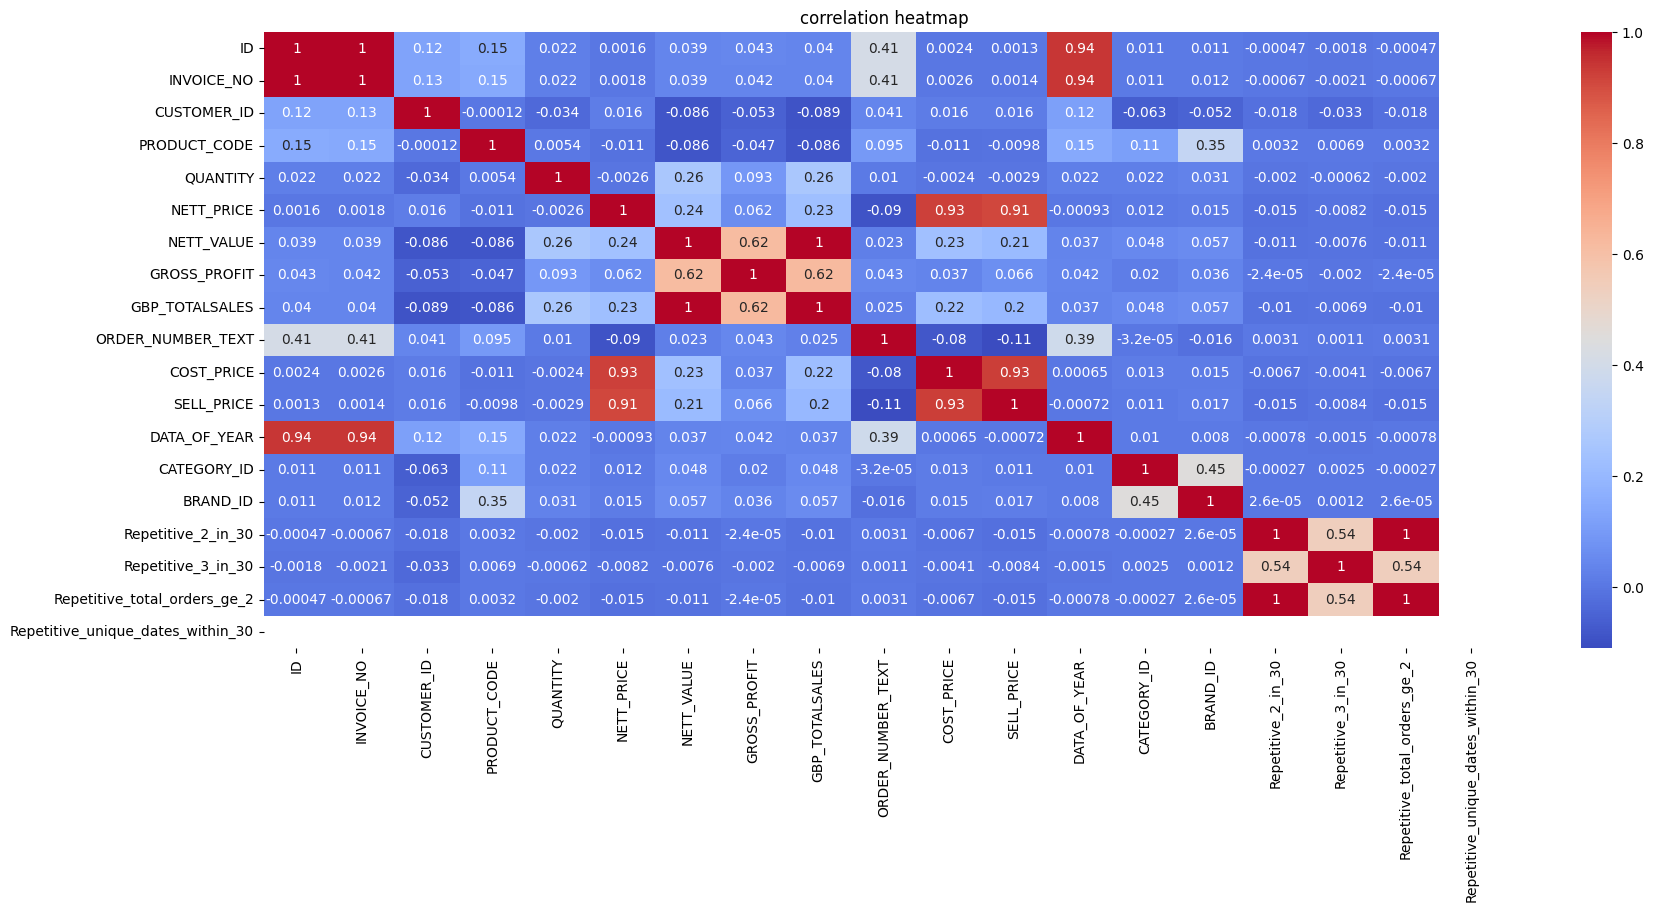

In [ ]:
plt.figure(figsize=(20,8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title("correlation heatmap")
plt.show()

In [ ]:
numeric_df.shape

(844180, 19)

In [ ]:
numeric_df = numeric_df.fillna('0')

In [ ]:
!pip install imblearn

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import log_loss, classification_report, confusion_matrix, roc_auc_score

In [ ]:
x = numeric_df.drop(columns=['Repetitive_2_in_30'],axis=1)
y = numeric_df['Repetitive_2_in_30']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
pca = PCA()
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

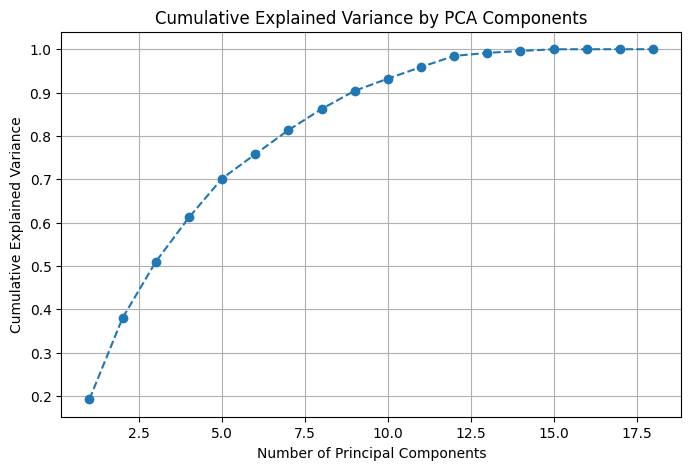

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [ ]:
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=500, random_state=42))
])
pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        24
           1       1.00      1.00      1.00    168812

    accuracy                           1.00    168836
   macro avg       0.98      0.96      0.97    168836
weighted avg       1.00      1.00      1.00    168836


Confusion Matrix:
[[    22      2]
 [     1 168811]]


In [ ]:
print(cleaned_df.dtypes)

ID                                            int64
INV_TYPE                                     object
INVOICE_NO                                    int64
INV_CREATED_DATE                     datetime64[ns]
CUSTOMER_ID                                   int64
CUSTOMER_NAME                                object
PRODUCT_CODE                                float64
PRODUCT_DESC                                 object
QUANTITY                                    float64
NETT_PRICE                                  float64
NETT_VALUE                                  float64
SALES_REP                                    object
GROSS_PROFIT                                float64
INV_CURRENCY                                 object
GBP_TOTALSALES                              float64
ORDER_NUMBER_TEXT                             int64
BRAND_NAME                                   object
REGION                                       object
PRODUCT_TYPE                                 object
PRODUCT     

In [ ]:
# Define target
target_col = 'Repetitive_2_in_30'

# Columns to drop (IDs, dates, target, duplicates)
drop_cols = [
    'ID', 'INVOICE_NO', 'ORDER_NUMBER_TEXT', 'CUSTOMER_ID', 'CUSTOMER_NAME',
    'order_date', 'Repetitive_2_in_30', 'Repetitive_3_in_30',
    'Repetitive_total_orders_ge_2', 'Repetitive_unique_dates_within_30'
]

# Drop all columns ending with _x or _y (duplicates from merges)
drop_cols += [c for c in cleaned_df.columns if c.endswith('_x') or c.endswith('_y') or c.startswith('flag_')]

# Keep only remaining columns as features
X = cleaned_df.drop(columns=drop_cols, errors='ignore')
y = cleaned_df[target_col]

print(f"Final shape of features: {X.shape}")
print("Sample columns used for modeling:\n", X.columns.tolist())


Final shape of features: (844180, 22)
Sample columns used for modeling:
 ['INV_TYPE', 'INV_CREATED_DATE', 'PRODUCT_CODE', 'PRODUCT_DESC', 'QUANTITY', 'NETT_PRICE', 'NETT_VALUE', 'SALES_REP', 'GROSS_PROFIT', 'INV_CURRENCY', 'GBP_TOTALSALES', 'BRAND_NAME', 'REGION', 'PRODUCT_TYPE', 'PRODUCT', 'COST_PRICE', 'SELL_PRICE', 'REC_FROM', 'DATA_OF_YEAR', 'CATEGORY_ID', 'BRAND_ID', 'InvRow']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numeric
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number', 'datetime']).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols), cat_cols)


Numeric columns: 11
Categorical columns: 10 ['INV_TYPE', 'PRODUCT_DESC', 'SALES_REP', 'INV_CURRENCY', 'BRAND_NAME', 'REGION', 'PRODUCT_TYPE', 'PRODUCT', 'REC_FROM', 'InvRow']


without smote

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# train/test split (same as before)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# transformers (OneHotEncoder as sparse to save memory)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))  # sparse=True -> memory friendly
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

# pipeline WITHOUT SMOTE but with class_weight to handle imbalance
pipeline = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1))
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.02      0.11      0.04        19
           1       1.00      1.00      1.00    168817

    accuracy                           1.00    168836
   macro avg       0.51      0.55      0.52    168836
weighted avg       1.00      1.00      1.00    168836

[[     2     17]
 [    82 168735]]


With smote

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # <-- use imblearn's Pipeline, not sklearn's

# train/test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- Transformers ---
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

# --- Full pipeline with SMOTE ---
pipeline = Pipeline(steps=[
    ('preproc', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
])

# Fit and evaluate
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.04      0.11      0.05        19
           1       1.00      1.00      1.00    168817

    accuracy                           1.00    168836
   macro avg       0.52      0.55      0.53    168836
weighted avg       1.00      1.00      1.00    168836


Confusion Matrix:
[[     2     17]
 [    54 168763]]


# Random Forest

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/record (1).csv")
df.head()

,ID,INV_UNIQUE,INV_TYPE,INV_INVOICE_NO,INV_CREATED,INV_UPDATED,INV_CREATED_DATE,INV_INVOICE_DATE,CUSTOMER_ACCOUNT_CODE,CUSTOMER_NAME,...,DATA_OF_YEAR,CREATEDDATE,MODIFYDATE,CATEGORY_ID,BRAND_ID,InvRow,OKFlag,Reason,GROSS_PMA_WEIGHT,ORD_PRICE
0,3343762,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,462.0,530868-0,1,NaN,7.120,0.0
1,3343763,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,529.0,530868-1,1,NaN,31.950,0.0
2,3343764,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,532.0,530868-2,1,NaN,20.070,0.0
3,3343765,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,462.0,530868-3,1,NaN,7.810,0.0
4,3343766,NaN,I,530868,NaN,NaN,00:00.0,00:00.0,117943,Raja Exotics Ltd,...,2022,01:10.9,00:59.7,12.0,524.0,530868-4,1,NaN,3.852,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844180 entries, 0 to 844179
Data columns (total 57 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     844180 non-null  int64  
 1   INV_UNIQUE             0 non-null       float64
 2   INV_TYPE               844180 non-null  object 
 3   INV_INVOICE_NO         844180 non-null  int64  
 4   INV_CREATED            0 non-null       float64
 5   INV_UPDATED            0 non-null       float64
 6   INV_CREATED_DATE       844180 non-null  object 
 7   INV_INVOICE_DATE       844180 non-null  object 
 8   CUSTOMER_ACCOUNT_CODE  844180 non-null  int64  
 9   CUSTOMER_NAME          844109 non-null  object 
 10  PMA_PART_ONLY          826270 non-null  float64
 11  FULL_DESC              832633 non-null  object 
 12  INV_QTY                844180 non-null  float64
 13  INV_NETT_PRICE         844180 non-null  float64
 14  INV_NETT_VALUE         844180 non-nu

In [ ]:
cleaned_df = df.drop(columns=['INV_CREATED', 'INV_UPDATED', 'PARAM_2', 'PARAM_3', 'INV_CURR_CONVERSION',
                              'PARAM_4', 'OBJECTS', 'INV_CURR_RATE', 'INV_ORDER_TYPE', 'INV_PAY_TERMS',
                              'INV_VAT_CODE', 'INV_VAT_PERCENT', 'INV_VAT_VALUE', 'PMA_WEIGHT',
                              'INV_NETT_PRI_H_PER', 'INV_NETT_PRI_H', 'INV_VAT_VAL_H', 'INV_GROSS_VALUE',
                              'INV_NETT_PRICE_PER', 'CREATEDDATE', 'MODIFYDATE','OKFlag',
                              'Reason', 'GROSS_PMA_WEIGHT', 'ORD_PRICE'],axis = 1,errors = "ignore")

In [ ]:
cleaned_df = cleaned_df.drop(columns = ['INV_UNIQUE','INV_INVOICE_DATE','INV_CREATED_BY','PARAM_1','AC'],axis=1)

In [ ]:
cleaned_df.shape

(844180, 27)

In [ ]:
cleaned_df = cleaned_df.rename(columns={
    'INV_INVOICE_NO': 'INVOICE_NO',
    'CUSTOMER_ACCOUNT_CODE': 'CUSTOMER_ID',
    'PMA_PART_ONLY': 'PRODUCT_CODE',
    'FULL_DESC' : 'PRODUCT_DESC',
    'INV_QTY' : 'QUANTITY',
    'INV_NETT_PRICE' : 'NETT_PRICE',
    'INV_NETT_VALUE' : 'NETT_VALUE',
    'PMA_ANAL_FIELD10' : 'BRAND_NAME',
    'PMA_ANAL_FIELD1' : 'REGION',
    'PMA_ANAL_FIELD2' : 'PRODUCT_TYPE',
    'PMA_ANAL_FIELD3' : 'PRODUCT'
})

In [ ]:
cleaned_df.shape

(844180, 27)

In [ ]:
cleaned_df['order_date'] = pd.to_datetime(cleaned_df['INV_CREATED_DATE'])
cleaned_df['order_date'].head()

,order_date
0,2025-11-09
1,2025-11-09
2,2025-11-09
3,2025-11-09
4,2025-11-09


In [ ]:
import pandas as pd
import numpy as np

# --- 0. ensure correct types ----------------------------------------------
cleaned_df['order_date'] = pd.to_datetime(cleaned_df['order_date'], errors='coerce')
invalid_dates = cleaned_df['order_date'].isna().sum()
if invalid_dates:
    print(f"Warning: {invalid_dates} rows have invalid order_date and will be dropped.")
    cleaned_df = cleaned_df.dropna(subset=['order_date'])

# --- 1. aggregate per customer (keep all orders list and unique-date list) ---
cust = cleaned_df.groupby('CUSTOMER_ID').agg(
    total_orders=('order_date', 'count'),
    num_unique_order_dates=('order_date', 'nunique'),
    dates_all=('order_date', lambda x: sorted(x.tolist())),                       # include duplicates (timestamps)
    dates_unique=('order_date', lambda x: sorted(pd.to_datetime(pd.Series(x).dt.normalize().unique())))  # unique calendar dates
).reset_index()

# --- helper: sliding window check for k orders inside window_days (works with timestamps) ---
def has_k_within_window(dates, window_days=30, k=2):
    if not dates or len(dates) < k:
        return False
    s = sorted(dates)
    left = 0
    for right in range(len(s)):
        # move left pointer until window fits
        while (s[right] - s[left]).days > window_days:
            left += 1
            if left > right:
                break
        if (right - left + 1) >= k:
            return True
    return False

# --- 2. compute chosen labels & some extras --------------------------------
cust['min_days_between_all_orders'] = cust['dates_all'].apply(
    lambda d: np.nan if len(d) < 2 else min((d[i+1] - d[i]).days for i in range(len(d)-1))
)

# Chosen label: at least 2 orders within any 30-day window (counts same-day)
cust['Repetitive_2_in_30'] = cust['dates_all'].apply(lambda d: 1 if has_k_within_window(d, window_days=30, k=2) else 0)

# Optional additional label: at least 3 orders in any 30-day window
cust['Repetitive_3_in_30'] = cust['dates_all'].apply(lambda d: 1 if has_k_within_window(d, window_days=30, k=3) else 0)

# Also keep a simpler label: total_orders >= 2 (counts same-day)
cust['Repetitive_total_orders_ge_2'] = (cust['total_orders'] >= 2).astype(int)

# And the strict unique-date label (repeat on different calendar days within 30 days)
def min_adjacent_diff_dates(dates):
    if not dates or len(dates) < 2:
        return np.nan
    return min((dates[i+1] - dates[i]).days for i in range(len(dates)-1))

cust['min_days_between_unique_dates'] = cust['dates_unique'].apply(min_adjacent_diff_dates)
cust['Repetitive_unique_dates_within_30'] = cust['min_days_between_unique_dates'].apply(
    lambda x: 1 if (pd.notna(x) and x <= 30) else 0
)

# --- 3. prepare flags to merge back safely --------------------------------
flags_for_merge = cust[['CUSTOMER_ID',
                        'Repetitive_2_in_30',
                        'Repetitive_3_in_30',
                        'Repetitive_total_orders_ge_2',
                        'Repetitive_unique_dates_within_30']].copy()

# If cleaned_df already has any of these columns, drop them first to avoid merge collisions
for col in flags_for_merge.columns:
    if col in cleaned_df.columns and col != 'CUSTOMER_ID':
        cleaned_df = cleaned_df.drop(columns=[col])

# Merge only flag columns back to the original dataframe
cleaned_df = cleaned_df.merge(flags_for_merge, on='CUSTOMER_ID', how='left')

# Fill NA flags with 0 (shouldn't be necessary but safe)
for col in ['Repetitive_2_in_30', 'Repetitive_3_in_30', 'Repetitive_total_orders_ge_2', 'Repetitive_unique_dates_within_30']:
    cleaned_df[col] = cleaned_df[col].fillna(0).astype(int)

# --- 4. diagnostics --------------------------------------------------------
print("Distribution (Repetitive_2_in_30):")
print(cleaned_df['Repetitive_2_in_30'].value_counts(dropna=False))

print("\nDistribution (Repetitive_total_orders_ge_2):")
print(cleaned_df['Repetitive_total_orders_ge_2'].value_counts(dropna=False))

print("\nDistribution (Repetitive_unique_dates_within_30):")
print(cleaned_df['Repetitive_unique_dates_within_30'].value_counts(dropna=False))

print("\nDistribution (Repetitive_3_in_30):")
print(cleaned_df['Repetitive_3_in_30'].value_counts(dropna=False))

# Show example customers flagged by the chosen label
print("\nExamples where Repetitive_2_in_30 == 1:")
print(cust[cust['Repetitive_2_in_30'] == 1].head()[[
    'CUSTOMER_ID', 'total_orders', 'num_unique_order_dates', 'min_days_between_all_orders'
]])


Distribution (Repetitive_2_in_30):
Repetitive_2_in_30
1    844084
0        96
Name: count, dtype: int64

Distribution (Repetitive_total_orders_ge_2):
Repetitive_total_orders_ge_2
1    844084
0        96
Name: count, dtype: int64

Distribution (Repetitive_unique_dates_within_30):
Repetitive_unique_dates_within_30
0    844180
Name: count, dtype: int64

Distribution (Repetitive_3_in_30):
Repetitive_3_in_30
1    843850
0       330
Name: count, dtype: int64

Examples where Repetitive_2_in_30 == 1:
   CUSTOMER_ID  total_orders  num_unique_order_dates  \
0       100006           573                       1   
1       100007          4264                       1   
2       100011           628                       1   
3       100022           419                       1   
4       100024           951                       1   

   min_days_between_all_orders  
0                          0.0  
1                          0.0  
2                          0.0  
3                          0.0  


In [ ]:
#cleaned_df = cleaned_df.drop(['Repetitive_Customer'	,'Repetitive_Within_30_Days','Repetitive_Customer_x'	,'Repetitive_Within_30_Days_x'	,'Repetitive_Customer_y',	'Repetitive_Within_30_Days_y'],axis=1)

In [ ]:
cleaned_df.head(2)

,ID,INV_TYPE,INVOICE_NO,INV_CREATED_DATE,CUSTOMER_ID,CUSTOMER_NAME,PRODUCT_CODE,PRODUCT_DESC,QUANTITY,NETT_PRICE,...,REC_FROM,DATA_OF_YEAR,CATEGORY_ID,BRAND_ID,InvRow,order_date,Repetitive_2_in_30,Repetitive_3_in_30,Repetitive_total_orders_ge_2,Repetitive_unique_dates_within_30
0,3343762,I,530868,00:00.0,117943,Raja Exotics Ltd,22026.0,Humza Veg Samosa 10x650g(20 pieces),1.0,27.99,...,hansa,2022,12.0,462.0,530868-0,2025-11-09,1,1,1,0
1,3343763,I,530868,00:00.0,117943,Raja Exotics Ltd,22596.0,Surya Frozen Cassava Chips 6x1kg,5.0,9.99,...,hansa,2022,12.0,529.0,530868-1,2025-11-09,1,1,1,0


In [ ]:
from datetime import datetime

current_date = datetime.now()

# Convert 'INV_CREATED_DATE' to datetime objects, coercing errors to NaT
cleaned_df['INV_CREATED_DATE'] = pd.to_datetime(cleaned_df['INV_CREATED_DATE'], errors='coerce')

rfm = cleaned_df.groupby('CUSTOMER_ID').agg({
    'INV_CREATED_DATE': lambda x: (current_date - x.max()).days,  # Recency (days since last purchase)
    'INVOICE_NO': 'nunique',  # Frequency (number of purchases)
    'NETT_VALUE': 'sum'       # Monetary (total spending)
}).rename(columns={
    'INV_CREATED_DATE': 'Recency',
    'INVOICE_NO': 'Frequency',
    'NETT_VALUE': 'Monetary'
})

print(rfm.sort_values('Monetary', ascending=False))

             Recency  Frequency     Monetary
CUSTOMER_ID                                 
101053             0       6740  80468251.89
117988             0       4135  71124211.22
100555             0       7259  66629736.81
101758             0      12420  43065458.95
113434             0       2733  22972765.64
...              ...        ...          ...
117921             0          2      -187.48
100260             0          2      -377.30
173832             0          1      -502.50
174194             0          1      -588.00
100900             0          3     -5199.70

[2772 rows x 3 columns]


In [ ]:
cleaned_df['Repetitive_2_in_30'].unique()

array([1, 0])

In [ ]:
numeric_df = cleaned_df.select_dtypes(include=["int64","float64"])
numeric_df.head(2)

,ID,INVOICE_NO,CUSTOMER_ID,PRODUCT_CODE,QUANTITY,NETT_PRICE,NETT_VALUE,GROSS_PROFIT,GBP_TOTALSALES,ORDER_NUMBER_TEXT,COST_PRICE,SELL_PRICE,DATA_OF_YEAR,CATEGORY_ID,BRAND_ID,Repetitive_2_in_30,Repetitive_3_in_30,Repetitive_total_orders_ge_2,Repetitive_unique_dates_within_30
0,3343762,530868,117943,22026.0,1.0,27.99,27.99,17.23,27.99,527099,10.76,27.99,2022,12.0,462.0,1,1,1,0
1,3343763,530868,117943,22596.0,5.0,9.99,49.95,6.55,49.95,527099,8.68,9.99,2022,12.0,529.0,1,1,1,0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from scipy.sparse import hstack, csr_matrix
from sklearn.impute import SimpleImputer

In [ ]:
cleaned_df.columns

Index(['ID', 'INV_TYPE', 'INVOICE_NO', 'INV_CREATED_DATE', 'CUSTOMER_ID',
       'CUSTOMER_NAME', 'PRODUCT_CODE', 'PRODUCT_DESC', 'QUANTITY',
       'NETT_PRICE', 'NETT_VALUE', 'SALES_REP', 'GROSS_PROFIT', 'INV_CURRENCY',
       'GBP_TOTALSALES', 'ORDER_NUMBER_TEXT', 'BRAND_NAME', 'REGION',
       'PRODUCT_TYPE', 'PRODUCT', 'COST_PRICE', 'SELL_PRICE', 'REC_FROM',
       'DATA_OF_YEAR', 'CATEGORY_ID', 'BRAND_ID', 'InvRow', 'order_date',
       'Repetitive_2_in_30', 'Repetitive_3_in_30',
       'Repetitive_total_orders_ge_2', 'Repetitive_unique_dates_within_30'],
      dtype='object')

In [ ]:
x = cleaned_df.drop(columns=['Repetitive_2_in_30'],axis=1)
y = cleaned_df['Repetitive_2_in_30']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42,test_size=0.2, stratify = y)

In [ ]:
num_cols = x.select_dtypes(include=np.number).columns.tolist()
cat_cols = x.select_dtypes(exclude=np.number).columns.tolist()

In [ ]:
num_imputer = SimpleImputer(strategy='median')
x_train_num = num_imputer.fit_transform(x_train[num_cols])
x_test_num  = num_imputer.transform(x_test[num_cols])


In [ ]:
cat_imputer = SimpleImputer(strategy='most_frequent')
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

if cat_cols:
    x_train_cat_imp = cat_imputer.fit_transform(x_train[cat_cols]).astype(str)
    x_test_cat_imp  = cat_imputer.transform(x_test[cat_cols]).astype(str)

    x_train_cat_ohe = ohe.fit_transform(x_train_cat_imp)
    x_test_cat_ohe  = ohe.transform(x_test_cat_imp)
else:
    x_train_cat_ohe = csr_matrix((len(x_train), 0))
    x_test_cat_ohe  = csr_matrix((len(x_test), 0))

In [ ]:
x_train_combined = hstack([
    csr_matrix(x_train_num) if not isinstance(x_train_num, csr_matrix) else x_train_num,
    x_train_cat_ohe
], format='csr')

x_test_combined = hstack([
    csr_matrix(x_test_num) if not isinstance(x_test_num, csr_matrix) else x_test_num,
    x_test_cat_ohe
], format='csr')

In [ ]:
smoteenn = SMOTEENN(random_state=42)
x_res_num, y_res = smoteenn.fit_resample(x_train_num, y_train)

In [ ]:
x_res_cat = x_train_cat_ohe[:len(y_res)]  # approximate alignment
x_res_combined = hstack([
    csr_matrix(x_res_num),
    x_res_cat
], format='csr')

In [ ]:
selector = SelectKBest(score_func=mutual_info_classif, k=15)
x_res_k = selector.fit_transform(x_res_combined.toarray(), y_res)  # needs dense input
x_test_k = selector.transform(x_test_combined.toarray()

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(x_res_k, y_res)
y_pred = rf.predict(x_test_k)

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))